In [29]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
sys.path.append("..")
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [30]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 9.09 ms, sys: 4.1 ms, total: 13.2 ms
Wall time: 12.9 ms
CPU times: user 4.88 ms, sys: 1.01 ms, total: 5.89 ms
Wall time: 5.88 ms
CPU times: user 904 μs, sys: 2.04 ms, total: 2.95 ms
Wall time: 2.9 ms


In [31]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel']
label_feature = ['spend']
treatment_feature = ['treatment']

In [32]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel', 'history_segment'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history', 'mens', 'womens']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 3 lớp Embedding và 4 lớp Projection.


In [33]:
epochs = 150
early_stop_metric = "ema_qini"
ema = True
ema_alpha = 0.25
patience = 20
shared_dropout = 0.0
outcome_dropout = 0
shared_hidden = 200
outcome_hidden = 100
uplift_ranking = 0
response_ranking = 0
print (f" epochs = {epochs}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")


 epochs = 150
 early stop = ema_qini
 use ema = True
 ema alpha = 0.25
 patience = 20


In [ ]:
import io
import optuna
from contextlib import redirect_stdout, redirect_stderr

# Minimize Optuna console noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Optuna search config (validation only)
seeds = [412312, 42, 1874, 902745, 1]
n_trials = 100
tpe_sampler_seed = 412312
n_startup_trials = 10
n_warmup_steps = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    grid_lr = trial.suggest_float("lr", 5e-5, 5e-3, log=True)
    grid_wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    grid_outcome_dropout = trial.suggest_float("outcome_dropout", 0.0, 0.7)
    grid_shared_dropout = trial.suggest_float("shared_dropout", 0.0, 0.7)
    grid_shared_hidden = trial.suggest_int("shared_hidden", 32, 500)
    grid_outcome_hidden = trial.suggest_int("outcome_hidden", 32, 500)
    grid_ema_alpha = trial.suggest_float("ema_alpha", 0.1, 0.4)
    grid_early_stop_start_epoch = trial.suggest_int("early_stop_start_epoch", 0, 50)

    val_loss_list = []
    for step, SEED in enumerate(seeds, start=1):
        seed_everything(SEED)

        tarnet = Tarnet(
            cate_dims=cat_dims,
            num_count=num_count,
            epochs=epochs,
            learning_rate=grid_lr,
            weight_decay=grid_wd,
            use_ema=ema,
            ema_alpha=grid_ema_alpha,
            patience=patience,
            shared_hidden=grid_shared_hidden,
            outcome_hidden=grid_outcome_hidden,
            outcome_dropout=grid_outcome_dropout,
            shared_dropout=grid_shared_dropout,
            early_stop_metric="loss",
            early_stop_start_epoch=grid_early_stop_start_epoch,
        )

        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            tarnet.fit(train_loader, val_loader)

        current_val_loss = float(tarnet.best_loss)
        if not np.isfinite(current_val_loss):
            current_val_loss = float(tarnet.validate(val_loader, epoch=0))

        val_loss_list.append(current_val_loss)

        # Report intermediate objective so Optuna can prune bad trials early
        interim_mean_loss = float(np.mean(val_loss_list))
        interim_std_loss = float(np.std(val_loss_list))
        interim_score = interim_mean_loss + interim_std_loss
        trial.report(interim_score, step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Calculate aggregated metrics across the 5 validation seeds
    mean_loss = float(np.mean(val_loss_list))
    std_loss = float(np.std(val_loss_list))

    # Penalize instability (higher std) while minimizing
    final_score = mean_loss + std_loss

    trial.set_user_attr("mean_val_loss", mean_loss)
    trial.set_user_attr("std_val_loss", std_loss)
    trial.set_user_attr("final_score", final_score)
    return final_score

def print_trial_callback(study, trial):
    value = float(trial.value) if trial.value is not None else float("nan")
    try:
        best_trial = study.best_trial
        best_value = float(best_trial.value) if best_trial.value is not None else float("nan")
        print(
            f"Finished trial {trial.number}: val loss: {value:.4f} - "
            f"with hyperparameters: {trial.params} | "
            f"best trial: {best_trial.number} loss: {best_value:.4f}",
            flush=True
        )
    except ValueError:
        # No completed trials yet (e.g., first trials are pruned)
        print(
            f"Finished trial {trial.number}: val loss: {value:.4f} - "
            f"with hyperparameters: {trial.params} | best trial: N/A",
            flush=True
        )

sampler = optuna.samplers.TPESampler(seed=tpe_sampler_seed)
# pruner = optuna.pruners.MedianPruner(
#     n_startup_trials=n_startup_trials,
#     n_warmup_steps=n_warmup_steps,
#     interval_steps=1

study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=n_trials, show_progress_bar=True, callbacks=[print_trial_callback])

trial_rows = []
for t in study.trials:
    if t.value is None:
        continue
    trial_rows.append({
        "trial": t.number,
        "lr": round(float(t.params["lr"]), 4),
        "weight_decay": round(float(t.params["weight_decay"]), 4),
        "shared_hidden": int(t.params["shared_hidden"]),
        "outcome_hidden": int(t.params["outcome_hidden"]),
        "shared_dropout": round(float(t.params["shared_dropout"]), 3),
        "outcome_dropout": round(float(t.params["outcome_dropout"]), 3),
        "ema_alpha": round(float(t.params["ema_alpha"]), 3),
        "mean_val_loss": float(t.value),
        "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan))
    })

df_grid = pd.DataFrame(trial_rows).sort_values("mean_val_loss", ascending=True).reset_index(drop=True)
best_params = study.best_params
best_cfg = pd.Series({
    "lr": float(best_params["lr"]),
    "weight_decay": float(best_params["weight_decay"]),
    "shared_hidden": int(best_params["shared_hidden"]),
    "outcome_hidden": int(best_params["outcome_hidden"]),
    "shared_dropout": float(best_params["shared_dropout"]),
    "outcome_dropout": float(best_params["outcome_dropout"]),
    "ema_alpha": float(best_params["ema_alpha"]),
    "mean_val_loss": float(study.best_value),
    "std_val_loss": float(study.best_trial.user_attrs.get("std_val_loss", np.nan))
})

  0%|          | 0/100 [00:00<?, ?it/s]

Finished trial 0: val loss: 414.5963 - with hyperparameters: {'lr': 0.00045041481661314923, 'weight_decay': 3.2543813547868006e-05, 'outcome_dropout': 0.285791981486852, 'shared_dropout': 0.3103695462655224, 'shared_hidden': 314, 'outcome_hidden': 416, 'ema_alpha': 0.3804266724144051, 'early_stop_start_epoch': 49} | best trial: 0 loss: 414.5963


Best trial: 0. Best value: 414.596:   1%|          | 1/100 [01:51<3:03:51, 111.43s/it]

Finished trial 1: val loss: 413.3111 - with hyperparameters: {'lr': 0.0007575917730271274, 'weight_decay': 0.0009021924395173594, 'outcome_dropout': 0.5732414541511881, 'shared_dropout': 0.21781161962472378, 'shared_hidden': 227, 'outcome_hidden': 112, 'ema_alpha': 0.164719334003314, 'early_stop_start_epoch': 34} | best trial: 1 loss: 413.3111


Best trial: 1. Best value: 413.311:   2%|▏         | 2/100 [03:34<2:53:45, 106.38s/it]

...

Best trial: 78. Best value: 412.82:  98%|█████████▊| 98/100 [1:40:38<03:08, 94.09s/it]

Finished trial 98: val loss: 413.5246 - with hyperparameters: {'lr': 0.004966203241575775, 'weight_decay': 0.0021522498712299946, 'outcome_dropout': 0.15213310344351025, 'shared_dropout': 0.014257707550745444, 'shared_hidden': 469, 'outcome_hidden': 188, 'ema_alpha': 0.13690862302425763, 'early_stop_start_epoch': 34} | best trial: 78 loss: 412.8197


Best trial: 78. Best value: 412.82:  99%|█████████▉| 99/100 [1:42:40<01:42, 102.39s/it]

Finished trial 99: val loss: 413.4265 - with hyperparameters: {'lr': 0.0018603109796018764, 'weight_decay': 0.0008059286177787944, 'outcome_dropout': 0.17683263846947495, 'shared_dropout': 0.07657221201396773, 'shared_hidden': 371, 'outcome_hidden': 208, 'ema_alpha': 0.11304226063001187, 'early_stop_start_epoch': 24} | best trial: 78 loss: 412.8197


Best trial: 78. Best value: 412.82: 100%|██████████| 100/100 [1:43:58<00:00, 62.39s/it]


In [35]:
from IPython.display import display

if 'study' not in globals():
    print('Run Cell 10 (Optuna tuning) first.')
else:
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best mean_Val_Loss: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

if 'best_cfg' in globals():
    print('\nBest config table:')
    display(best_cfg.to_frame().T)
else:
    print('\nbest_cfg not found.')

if 'df_grid' in globals():
    print('\nTop 10 trials:')
    display(df_grid.head(10))
else:
    print('\ndf_grid not found.')

if 'df_results' in globals():
    print('\nPer-seed test results:')
    display(df_results)
    print('\nTest metrics mean ± std:')
    display(df_results.drop(columns='Seed').agg(['mean', 'std']))

Best trial: 78
Best mean_Val_Loss: 412.819659
Best params: {'lr': 0.002870628209544518, 'weight_decay': 0.0029259095646233676, 'outcome_dropout': 0.0761531045777782, 'shared_dropout': 0.047984910812982326, 'shared_hidden': 360, 'outcome_hidden': 161, 'ema_alpha': 0.11209677970062285, 'early_stop_start_epoch': 24}

Best config table:


,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,ema_alpha,mean_val_loss,std_val_loss
0,0.002871,0.002926,360.0,161.0,0.047985,0.076153,0.112097,412.819659,0.162948



Top 10 trials:


,trial,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,ema_alpha,mean_val_loss,std_val_loss
0,78,0.0029,0.0029,360,161,0.048,0.076,0.112,412.819659,0.162948
1,91,0.0030,0.0027,445,171,0.002,0.162,0.109,412.865759,0.200955
2,69,0.0005,0.0016,265,170,0.156,0.618,0.108,412.925451,0.112774
3,54,0.0007,0.0013,333,107,0.216,0.601,0.162,412.935887,0.037421
4,89,0.0026,0.0044,433,177,0.031,0.079,0.107,412.950812,0.177732
5,76,0.0012,0.0014,336,158,0.063,0.067,0.112,412.976051,0.148815
6,85,0.0032,0.0049,432,193,0.011,0.002,0.105,412.980783,0.137006
7,84,0.0028,0.0057,387,215,0.072,0.100,0.100,413.022664,NaN
8,80,0.0030,0.0026,407,195,0.030,0.020,0.113,413.031393,0.198033
9,74,0.0012,0.0014,311,154,0.060,0.081,0.114,413.031815,0.229747



Per-seed test results:


,Seed,AUUC,AUQC,Lift,KRCC,ATE_Err
0,412312,0.589866,0.586566,1.274909,0.049977,0.098193
1,42,0.628535,0.624791,1.423326,0.045488,0.009682
2,1874,0.608962,0.605103,1.544771,0.054510,0.125408
3,902745,0.589738,0.586789,1.367196,0.044209,0.222457
4,1,0.644153,0.638800,1.491551,0.082016,0.363491
5,2,0.556174,0.554821,1.433351,0.005150,0.117498
6,3,0.609585,0.606371,1.391107,0.085075,0.116644
7,4,0.540121,0.538995,1.165889,-0.023728,0.142148
8,5,0.533942,0.531362,0.984021,0.034688,0.206341
9,6,0.587543,0.585305,1.374926,0.062668,0.040371



Test metrics mean ± std:


,AUUC,AUQC,Lift,KRCC,ATE_Err
mean,0.588862,0.585890,1.345105,0.044005,0.144223
std,0.036406,0.035341,0.165375,0.033019,0.100497


Evaluating on test with best validation config:
  lr=2.9e-03, weight_decay=2.9e-03
  shared_hidden=360, outcome_hidden=161
  shared_dropout=0.048, outcome_dropout=0.076
  ema_alpha=0.112
Number of seeds: 10
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 605.7672 | Total Loss: 605.7672 | Val Loss: 413.6868 | Val Qini: 0.8076 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 251.1571 | Total Loss: 251.1571 | Val Loss: 413.9356 | Val Qini: 0.7773 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 508.8245 | Total Loss: 508.8245 | Val Loss: 413.2569 | Val Qini: 0.8335 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 980.2487 | Total Loss: 980.2487 | Val Loss: 413.7064 | Val Qini:

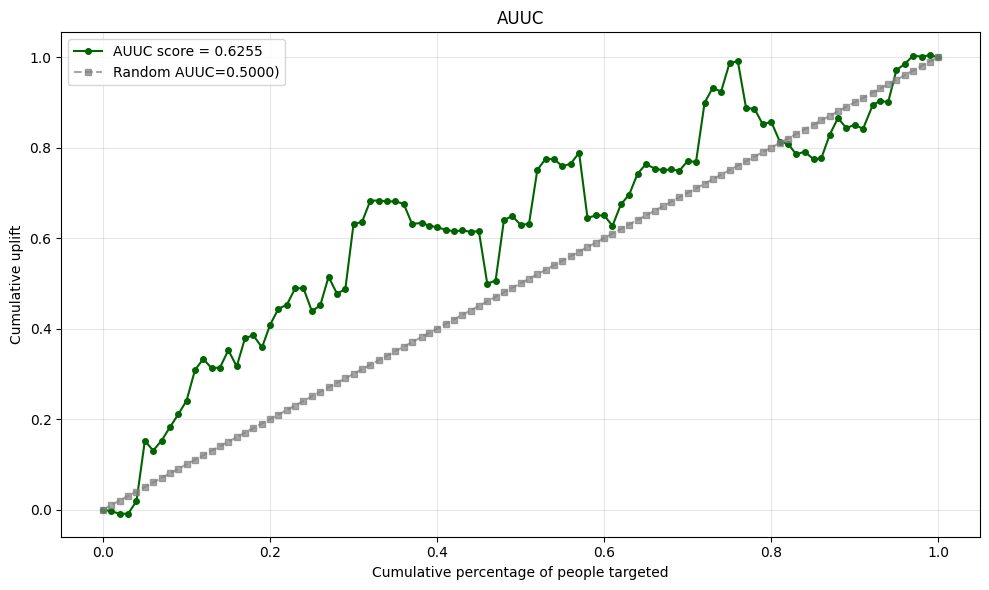

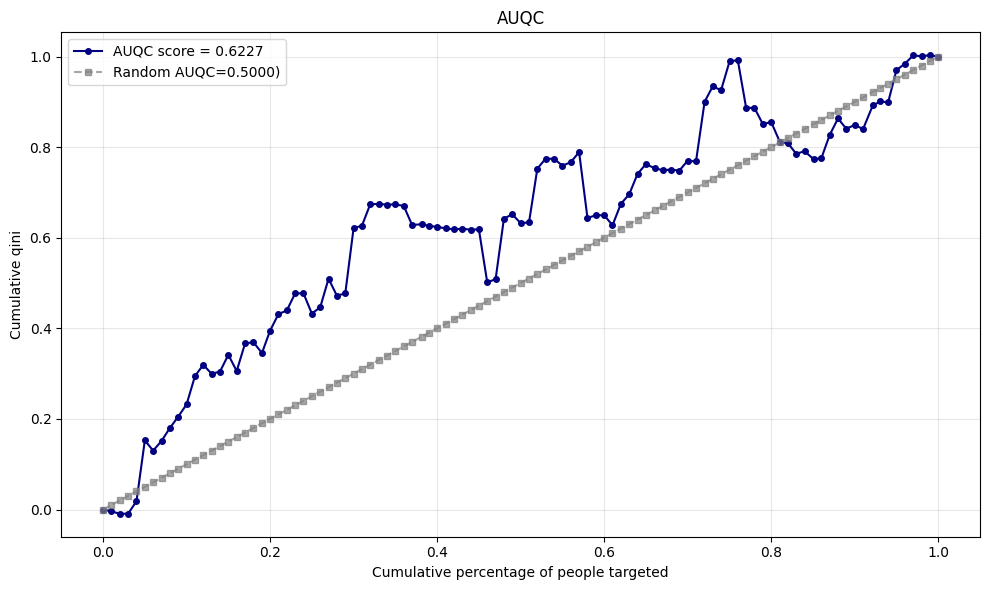

Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 901.5575 | Total Loss: 901.5575 | Val Loss: 413.6814 | Val Qini: 0.8147 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 85.5831 | Total Loss: 85.5831 | Val Loss: 413.3014 | Val Qini: 0.8401 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 386.3178 | Total Loss: 386.3178 | Val Loss: 413.3262 | Val Qini: 0.8664 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 427.7276 | Total Loss: 427.7276 | Val Loss: 414.2379 | Val Qini: 0.8289 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 148.0000 | Total Loss: 148.0000 | Val Loss: 413.1816 | Val Qini: 0.8035 (ignored before score selecti

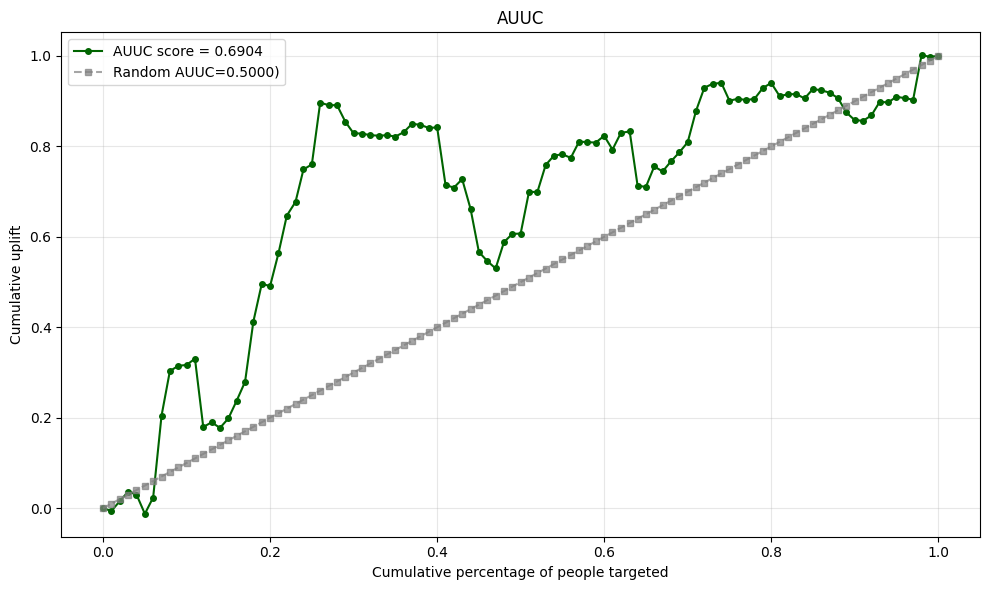

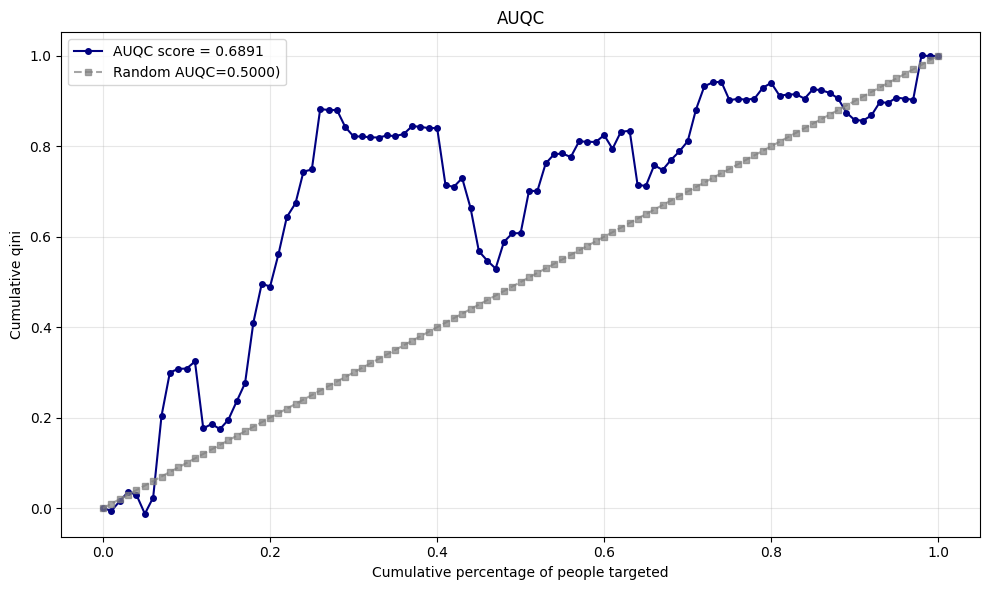

Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 428.4783 | Total Loss: 428.4783 | Val Loss: 413.4743 | Val Qini: 0.7107 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 324.6466 | Total Loss: 324.6466 | Val Loss: 414.1387 | Val Qini: 0.7317 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 461.8185 | Total Loss: 461.8185 | Val Loss: 413.2729 | Val Qini: 0.8081 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 437.8234 | Total Loss: 437.8234 | Val Loss: 413.3924 | Val Qini: 0.8302 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 410.9347 | Total Loss: 410.9347 | Val Loss: 413.0829 | Val Qini: 0.8113 (ignored before score selection

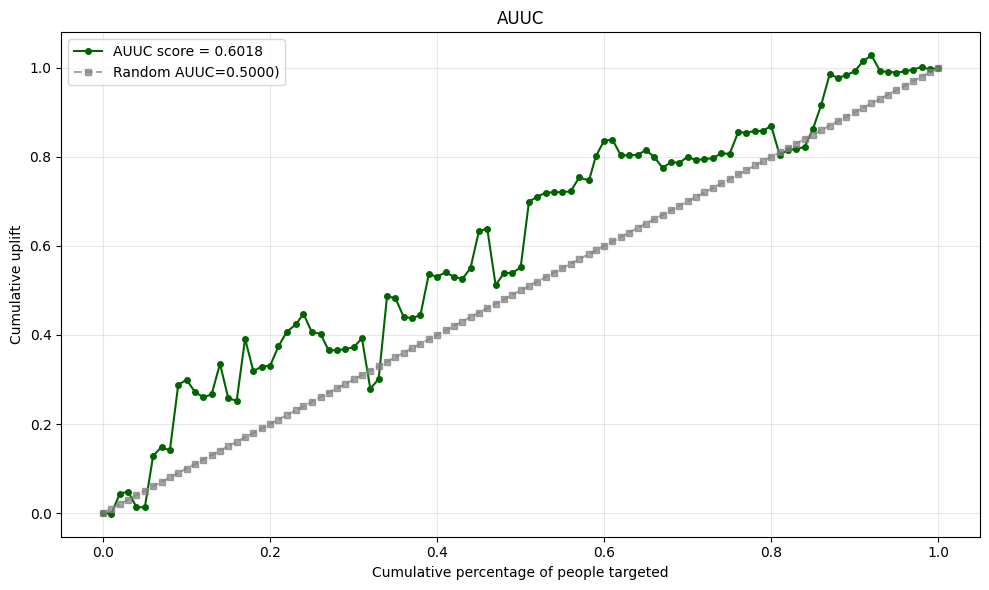

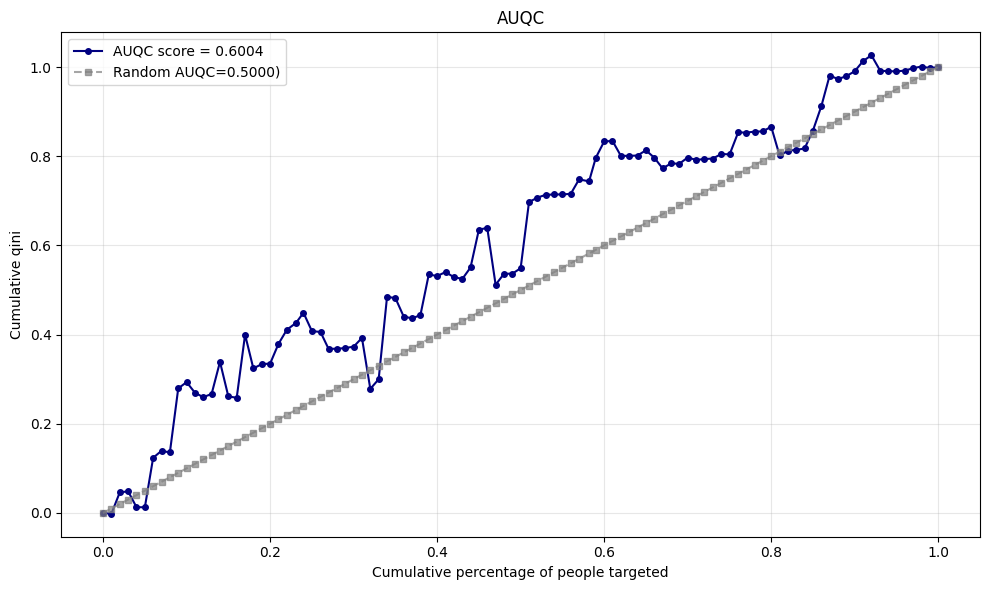

Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 463.6235 | Total Loss: 463.6235 | Val Loss: 413.6605 | Val Qini: 0.7864 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 1129.5988 | Total Loss: 1129.5988 | Val Loss: 413.7415 | Val Qini: 0.8286 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 616.6337 | Total Loss: 616.6337 | Val Loss: 413.4427 | Val Qini: 0.8184 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 501.9374 | Total Loss: 501.9374 | Val Loss: 413.6383 | Val Qini: 0.8308 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 201.1894 | Total Loss: 201.1894 | Val Loss: 413.3251 | Val Qini: 0.8280 (ignored before score selec

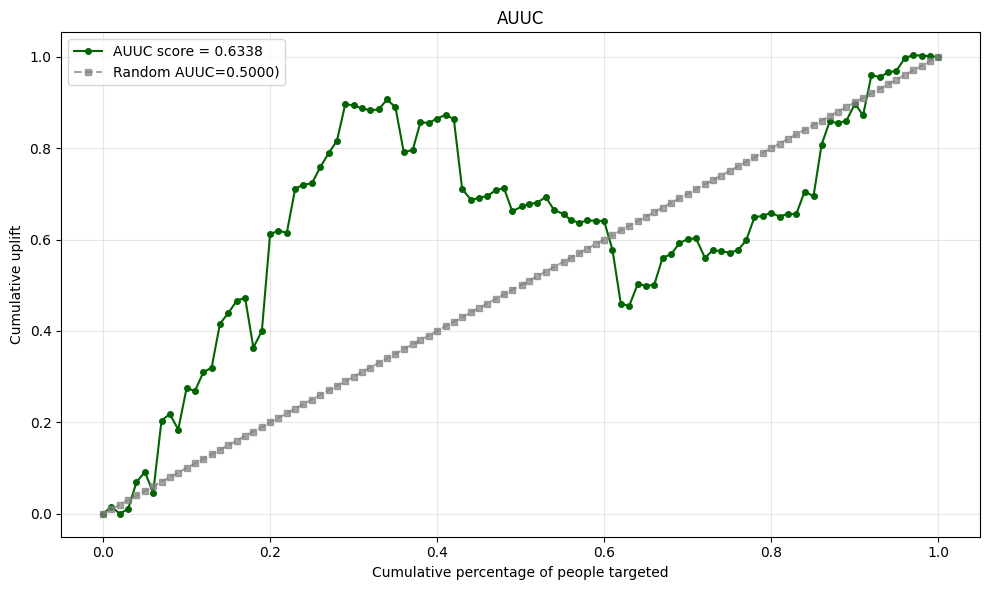

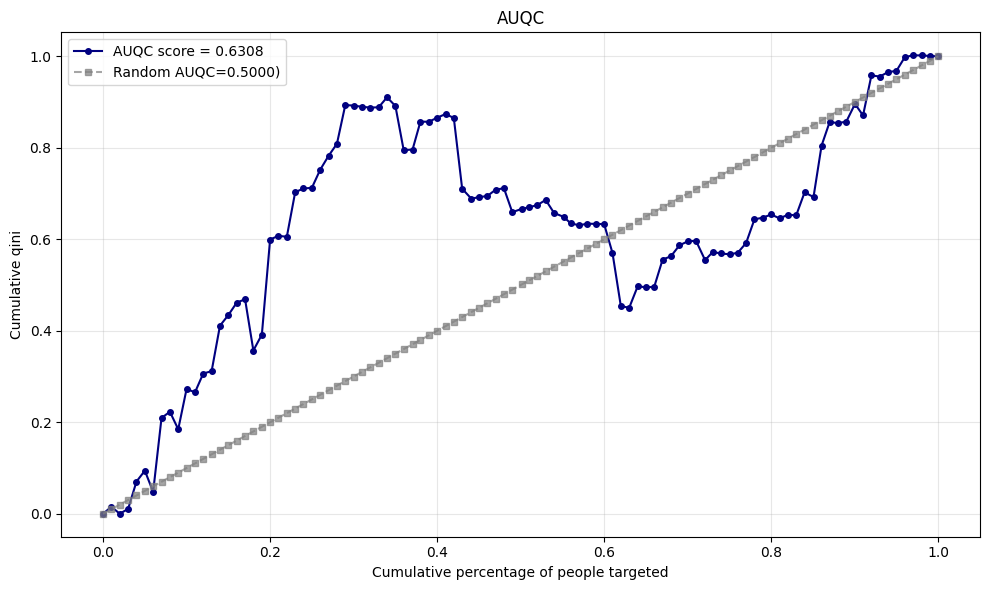

Done Seed 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 466.9093 | Total Loss: 466.9093 | Val Loss: 413.2892 | Val Qini: 0.8472 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 819.1091 | Total Loss: 819.1091 | Val Loss: 413.3504 | Val Qini: 0.8232 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 53.5201 | Total Loss: 53.5201 | Val Loss: 413.3873 | Val Qini: 0.7780 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 371.7255 | Total Loss: 371.7255 | Val Loss: 413.4934 | Val Qini: 0.7721 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 176.0125 | Total Loss: 176.0125 | Val Loss: 413.3806 | Val Qini: 0.7658 (ignored before score selecti

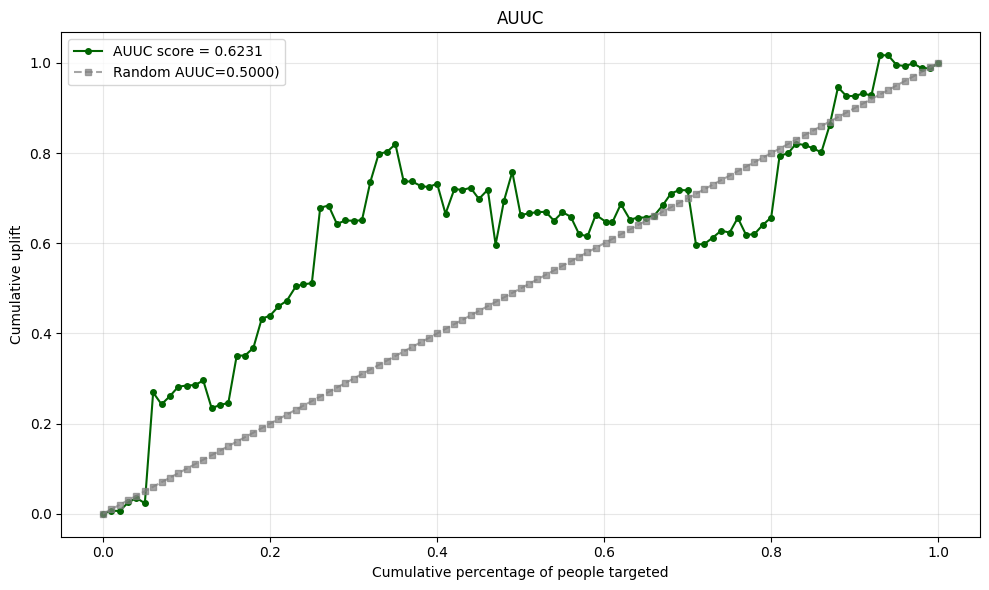

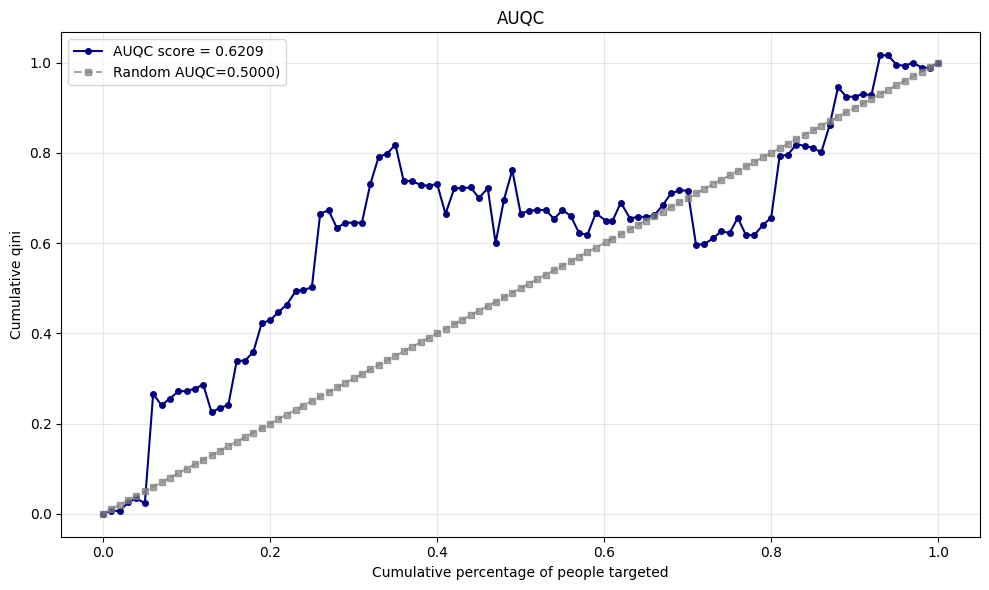

Done Seed 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 658.8401 | Total Loss: 658.8401 | Val Loss: 414.0864 | Val Qini: 0.8126 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 685.1074 | Total Loss: 685.1074 | Val Loss: 413.9084 | Val Qini: 0.8338 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 191.3563 | Total Loss: 191.3563 | Val Loss: 414.1720 | Val Qini: 0.8301 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 162.4771 | Total Loss: 162.4771 | Val Loss: 413.4550 | Val Qini: 0.8111 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 282.8290 | Total Loss: 282.8290 | Val Loss: 413.6545 | Val Qini: 0.8379 (ignored before score selection 

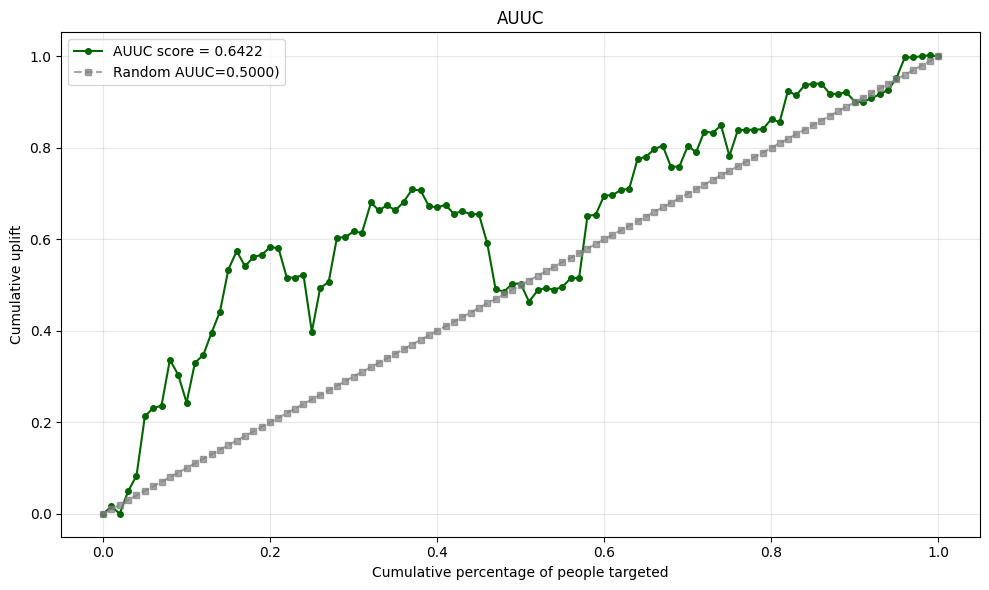

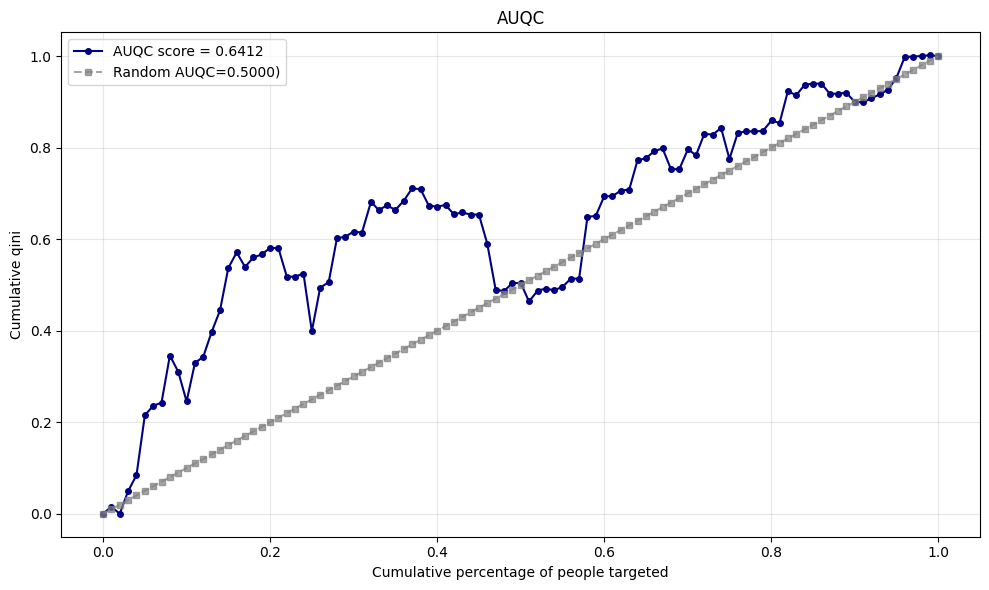

Done Seed 2
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 82.2324 | Total Loss: 82.2324 | Val Loss: 413.3932 | Val Qini: 0.7993 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 85.9431 | Total Loss: 85.9431 | Val Loss: 413.5286 | Val Qini: 0.8059 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 493.5045 | Total Loss: 493.5045 | Val Loss: 413.6473 | Val Qini: 0.7985 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 888.9301 | Total Loss: 888.9301 | Val Loss: 414.0672 | Val Qini: 0.7913 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 459.9089 | Total Loss: 459.9089 | Val Loss: 415.6332 | Val Qini: 0.8205 (ignored before score selection star

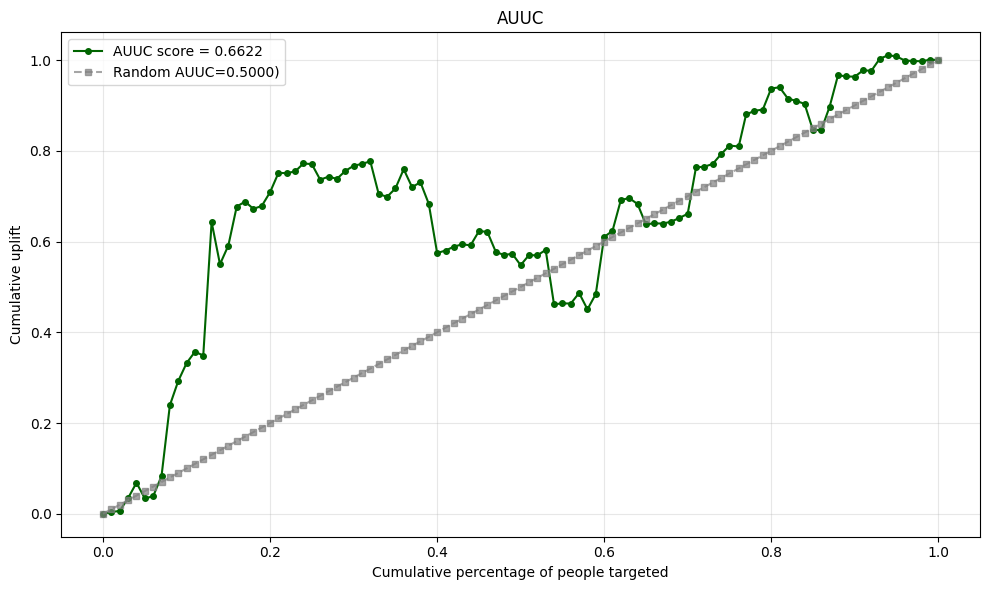

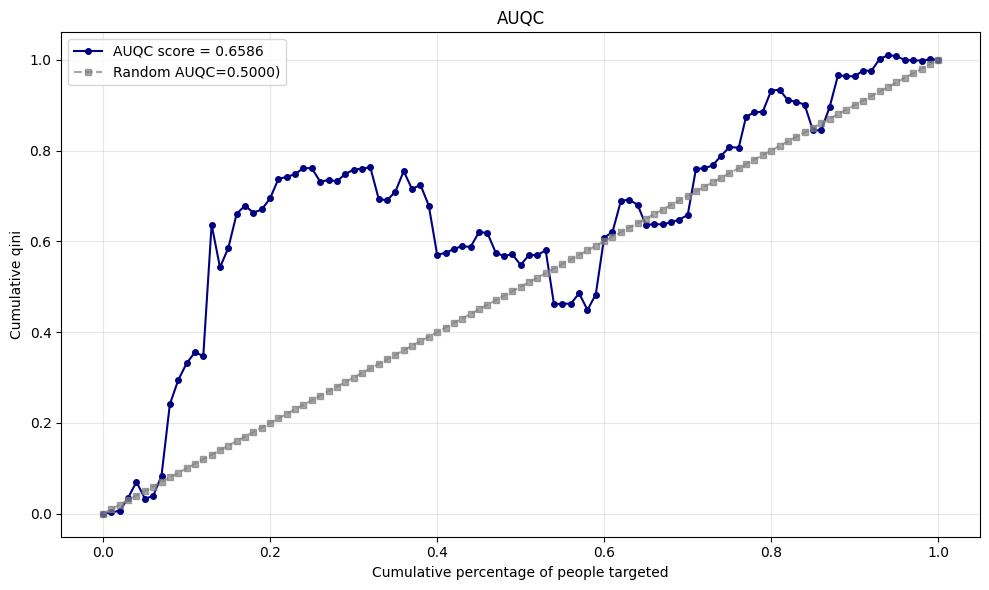

Done Seed 3
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 591.7660 | Total Loss: 591.7660 | Val Loss: 413.3348 | Val Qini: 0.8574 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 1158.5183 | Total Loss: 1158.5183 | Val Loss: 413.5030 | Val Qini: 0.8271 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 363.6396 | Total Loss: 363.6396 | Val Loss: 413.7426 | Val Qini: 0.8286 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 840.6014 | Total Loss: 840.6014 | Val Loss: 413.6641 | Val Qini: 0.6885 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 491.6133 | Total Loss: 491.6133 | Val Loss: 414.1585 | Val Qini: 0.7975 (ignored before score selectio

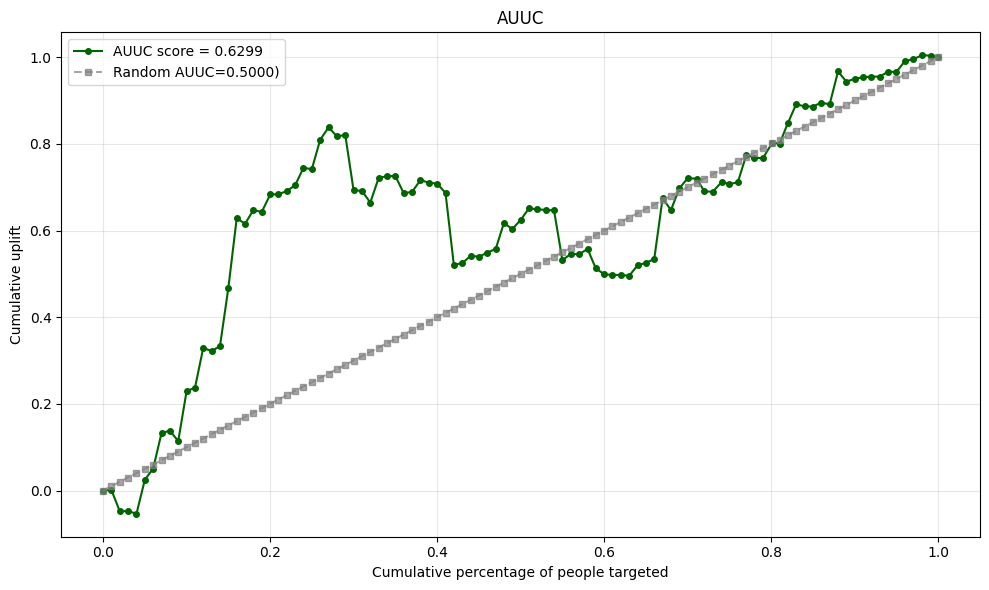

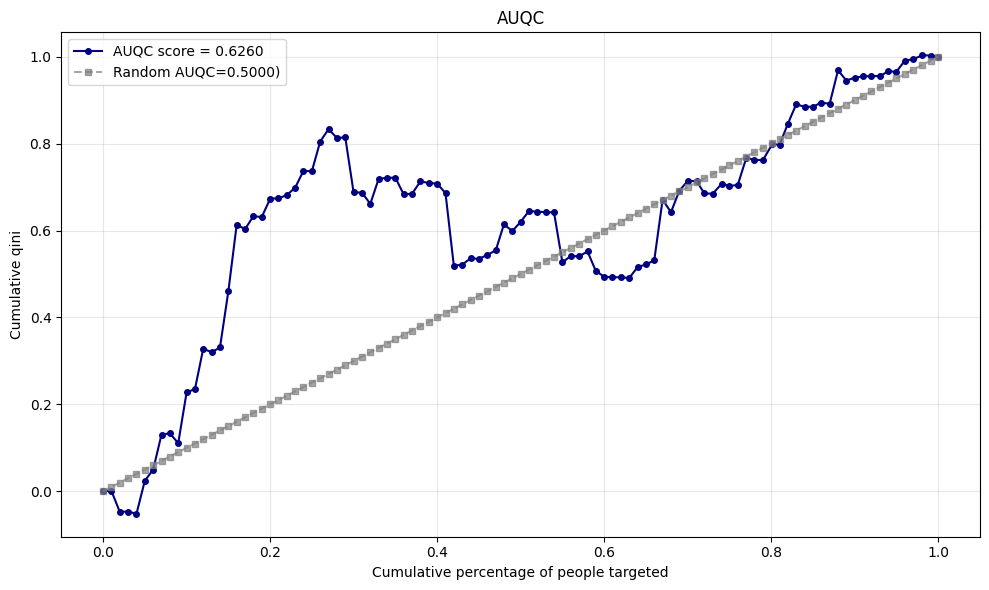

Done Seed 4
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 626.0753 | Total Loss: 626.0753 | Val Loss: 414.3655 | Val Qini: 0.6628 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 506.5319 | Total Loss: 506.5319 | Val Loss: 413.4112 | Val Qini: 0.7871 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 454.3443 | Total Loss: 454.3443 | Val Loss: 413.6949 | Val Qini: 0.1488 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 421.1196 | Total Loss: 421.1196 | Val Loss: 413.9642 | Val Qini: 0.8579 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 731.7536 | Total Loss: 731.7536 | Val Loss: 413.3744 | Val Qini: 0.8430 (ignored before score selection 

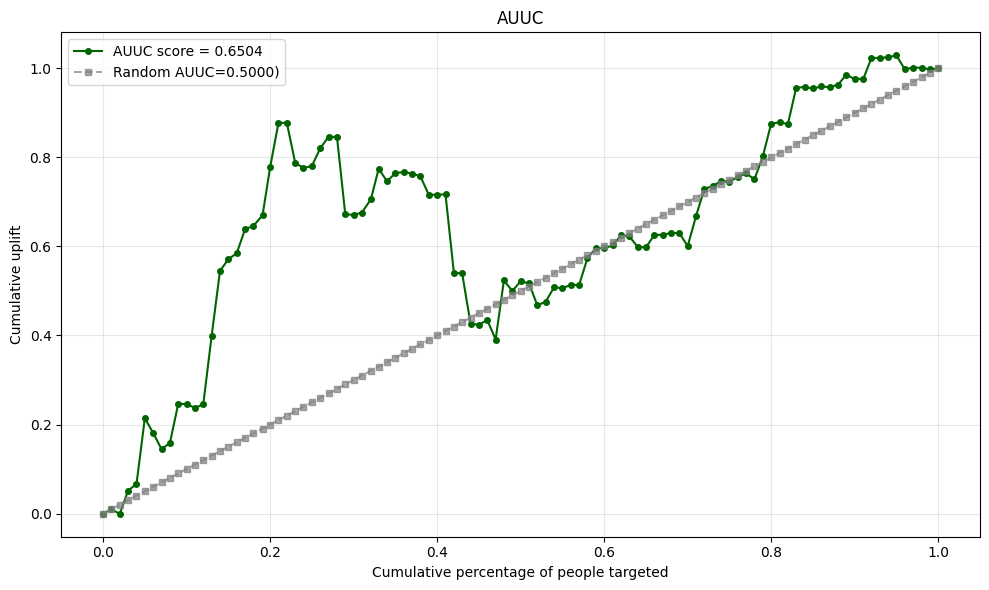

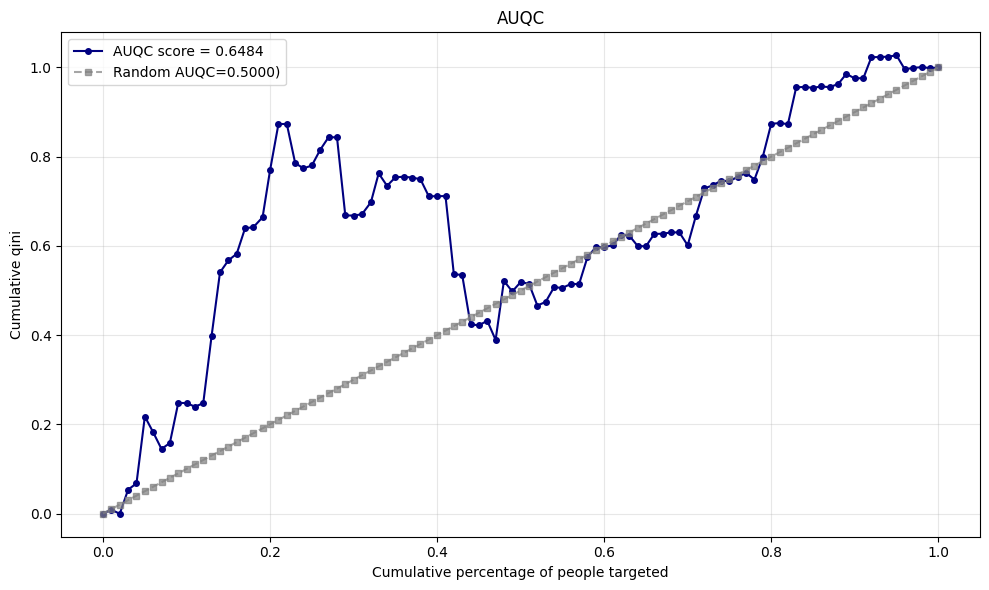

Done Seed 5
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 25
📊 Score Selection Start Epoch: 25 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 261.7444 | Total Loss: 261.7444 | Val Loss: 413.6764 | Val Qini: 0.8405 (ignored before score selection start epoch) | LR: 0.0029
Epoch 2/150 | Base Loss: 729.7515 | Total Loss: 729.7515 | Val Loss: 413.9506 | Val Qini: 0.7968 (ignored before score selection start epoch) | LR: 0.0029
Epoch 3/150 | Base Loss: 150.9652 | Total Loss: 150.9652 | Val Loss: 413.4596 | Val Qini: 0.7687 (ignored before score selection start epoch) | LR: 0.0029
Epoch 4/150 | Base Loss: 603.7393 | Total Loss: 603.7393 | Val Loss: 413.5521 | Val Qini: 0.7335 (ignored before score selection start epoch) | LR: 0.0029
Epoch 5/150 | Base Loss: 651.5271 | Total Loss: 651.5271 | Val Loss: 413.9560 | Val Qini: 0.7415 (ignored before score selection 

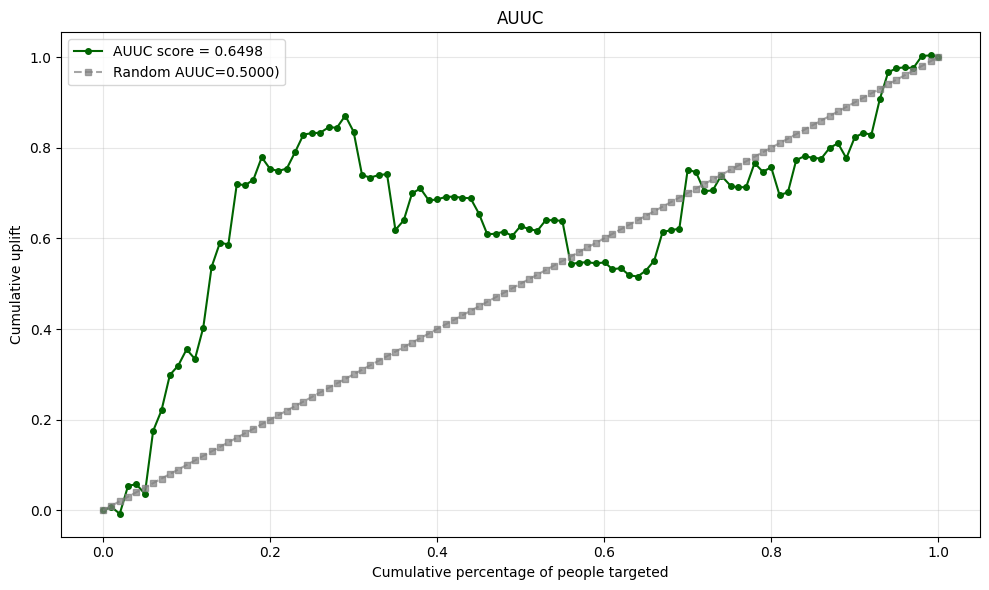

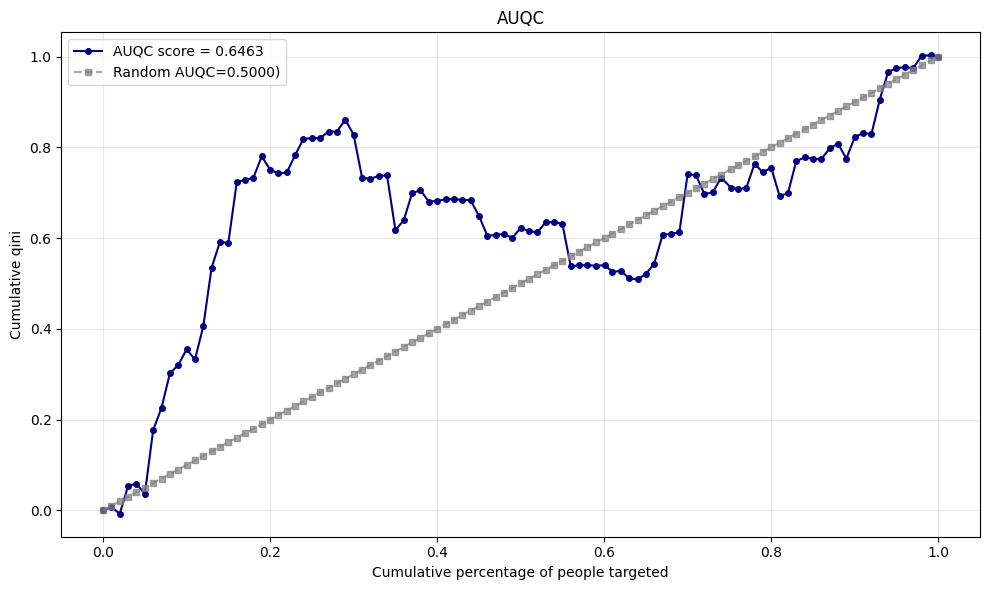

Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC   Lift   KRCC ATE_Err
412312 0.6255 0.6227 1.2376 0.0594  0.2662
    42 0.6904 0.6891 1.6219 0.0990  0.1781
  1874 0.6018 0.6004 0.7294 0.0353  0.0423
902745 0.6338 0.6308 1.7498 0.0816  0.4084
     1 0.6231 0.6209 1.2732 0.0576  0.1522
     2 0.6422 0.6412 1.2089 0.0970  0.1779
     3 0.6622 0.6586 1.5005 0.1115  0.2445
     4 0.6299 0.6260 1.3571 0.0426  0.2334
     5 0.6504 0.6484 1.3133 0.0841  0.2722
     6 0.6498 0.6463 1.6346 0.0415  0.3452
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.6409 ± 0.0243
AUQC      : 0.6384 ± 0.0244
Lift      : 1.3626 ± 0.2908
KRCC      : 0.0710 ± 0.0272
ATE_Err   : 0.2320 ± 0.1028


In [38]:
# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1,2,3,4,5,6] # Extended to 10 seeds for more robust evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

if 'best_cfg' not in globals():
    raise ValueError("best_cfg not found. Run grid-search cell first.")

best_lr = float(best_cfg['lr'])
best_wd = float(best_cfg['weight_decay'])
best_shared_hidden = int(best_cfg['shared_hidden'])
best_outcome_hidden = int(best_cfg['outcome_hidden'])
best_shared_dropout = float(best_cfg['shared_dropout'])
best_outcome_dropout = float(best_cfg['outcome_dropout'])
best_ema_alpha = float(best_cfg['ema_alpha'])

print("Evaluating on test with best validation config:")
print(f"  lr={best_lr:.1e}, weight_decay={best_wd:.1e}")
print(f"  shared_hidden={best_shared_hidden}, outcome_hidden={best_outcome_hidden}")
print(f"  shared_dropout={best_shared_dropout:.3f}, outcome_dropout={best_outcome_dropout:.3f}")
print(f"  ema_alpha={best_ema_alpha:.3f}")
print(f"Number of seeds: {len(seeds)}")

# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=150,
        learning_rate=best_lr,
        weight_decay=best_wd,
        use_ema=ema,
        ema_alpha=best_ema_alpha,
        patience=20,
        shared_hidden=best_shared_hidden,
        outcome_hidden=best_outcome_hidden,
        outcome_dropout=best_outcome_dropout,
        shared_dropout=best_shared_dropout,
        early_stop_metric="loss",
        early_stop_start_epoch=24
    )

    tarnet.fit(train_loader, val_loader)

    # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)

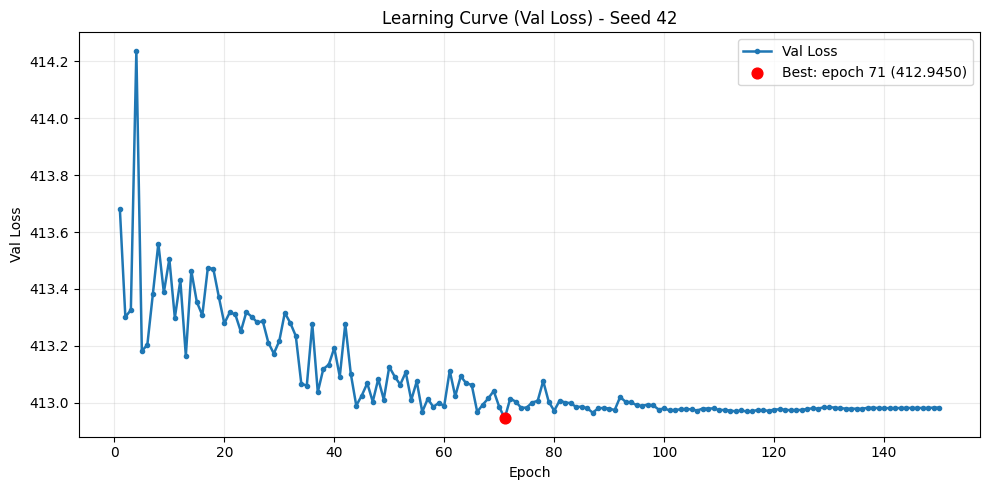

Parsed 150 val-loss points.
Best Val Loss: 412.9450 at epoch 71
Saved val-loss curve to: val_loss_curve_seed_42.csv


In [37]:
import re
import io
from contextlib import redirect_stdout, redirect_stderr
import matplotlib.pyplot as plt
import pandas as pd

# Plot learning curve (Val Loss) for one specific seed
seed_to_plot = 42

seed_everything(seed_to_plot)
tarnet_seed = Tarnet(
    cate_dims=cat_dims,
    num_count=num_count,
    epochs=150,
    learning_rate=best_lr,
    weight_decay=best_wd,
    use_ema=True,
    ema_alpha=best_ema_alpha,
    patience=150,
    shared_hidden=best_shared_hidden,
    outcome_hidden=best_outcome_hidden,
    outcome_dropout=best_outcome_dropout,
    shared_dropout=best_shared_dropout,
    early_stop_metric="loss",
    early_stop_start_epoch=0,
 )

# Capture training logs so we can parse validation loss per epoch
buffer = io.StringIO()
with redirect_stdout(buffer), redirect_stderr(buffer):
    tarnet_seed.fit(train_loader, val_loader)

train_log = buffer.getvalue()

# Parse lines like: "Epoch 51/150 ... Val Loss: 1.2345 ..."
pattern = re.compile(r"Epoch\s+(\d+)/(\d+).*?Val Loss:\s+([0-9]*\.?[0-9]+)")
epochs_curve, val_loss_curve = [], []

for line in train_log.splitlines():
    m = pattern.search(line)
    if not m:
        continue
    epoch_idx = int(m.group(1))
    val_loss = float(m.group(3))
    epochs_curve.append(epoch_idx)
    val_loss_curve.append(val_loss)

if len(epochs_curve) == 0:
    raise ValueError("No Val Loss values found in training logs.")

best_i = int(min(range(len(val_loss_curve)), key=lambda i: val_loss_curve[i]))

# Save validation loss curve
val_loss_curve_df = pd.DataFrame({
    "epoch": epochs_curve,
    "val_loss": val_loss_curve
})
val_loss_curve_path = f"val_loss_curve_seed_{seed_to_plot}.csv"
val_loss_curve_df.to_csv(val_loss_curve_path, index=False)

plt.figure(figsize=(10, 5))
plt.plot(epochs_curve, val_loss_curve, marker='o', linewidth=1.8, markersize=3, label='Val Loss')
plt.scatter(
    [epochs_curve[best_i]],
    [val_loss_curve[best_i]],
    color='red',
    s=60,
    zorder=3,
    label=f"Best: epoch {epochs_curve[best_i]} ({val_loss_curve[best_i]:.4f})"
 )
plt.title(f"Learning Curve (Val Loss) - Seed {seed_to_plot}")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Parsed {len(val_loss_curve)} val-loss points.")
print(f"Best Val Loss: {val_loss_curve[best_i]:.4f} at epoch {epochs_curve[best_i]}")
print(f"Saved val-loss curve to: {val_loss_curve_path}")